<a href="https://colab.research.google.com/github/estebancardonad/Trabajos_Python_xd/blob/main/Sesi%C3%B3n_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p><img alt="Colaboratory logo" height="120px" src="https://www.udea.edu.co/wps/wcm/connect/udea/df55724e-3ebc-46c6-b608-fb9206b3fede/facultad-economicas.png?MOD=AJPERES&CVID=nc5zPyj" align="Center" hspace="10px" vspace="10px"></p>


#***Python I - Introducción a modelos económicos y financieros con Python***



In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [4]:
##Importar librerias
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
import matplotlib as plt

##Taller

A continuación cargaremos dos bases de datos con información referente a tarjetas de credito del mes 09 del 2017.

El archivo ESTADO_201709.txt tal que:

* ID:​ Nro. de identificación.
* Franquicia:​ A, B, C.
* Tipo Tarjeta:​ Representa el tipo de tarjeta.
* Número Tarjeta:​ Indica el número de la TC.
* Cupo Global:​ Indica el cupo de crédito que tiene la tarjeta.
* Disponible: Indica del cupo global cuanto tiene a ese corte disponible para realizar compras o avances.
* Fecha Emisión:​ Fecha en la que se compró la tarjeta.
* Fecha Ult Aumento Cupo: Fecha en la que se realizó el último aumento de cupo. Cuando está en 0 significa que nunca se ha realizado un aumento de cupo.
* Total Mes en Mora: Número de meses que ha estado en mora la TC (durante toda
la vida de la tarjeta).
*Altura de Mora: ​Indica la mora actual que tiene la TC. Viene en rango:
  ○ 0 No está en mora,
  ○ 30 está en mora hace menos de 30 días,
  ○ 60 está en mora hace menos de 60 días.
  ○ 90 está en mora hace menos de 90 días.
*Código Vendedor:​ Indica el código del vendedor que emitió la TC.
*Código Estado Tarjeta: Indica si la tarjeta está Activa o vigente (Codigo=0) y código = 1 (indica que la tarjeta está cancelada por el cliente).

Y el archivo TRANSACCION_201709.txt, tal que:

* ID:​ Nro de identificación.
* Número Tarjeta:​ Indica el número de la TC que realizó la transacción.
* Fecha de transacción​: Indica la fecha en que se realizó la transacción.
* Codigo Transacción:
  ○ AV : AVANCE
  ○ AB: ABONO
  ○ CN: COMPRA NACIONAL
  ○ CI: COMPRA INTERNAL
  ○ CM: CUOTA DE MANEJO.
* Valor Transacción:​ Indica el valor de la transacción.
* Numero Cuotas Diferidas: Indica el número de cuotas en el que el cliente desea pagar la compra.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = 'https://raw.githubusercontent.com/diplomado-bigdata-machinelearning-udea/Curso1/master/s04/'
dfE = pd.read_csv(path+'ESTADO_201709.txt', delimiter="|")
dfT = pd.read_csv(path+'TRANSACCION_201709.txt', delimiter="|")

### Responda
1. Imprima cada uno de los datasets para ver sus columnas
2. Use el método merge para combinar los datasets  en el `NUMERO TARJETA' y haciendo la intersección.
3. Busque los datos faltantes y determine una estrategia adecuada par su llenado.
4. Convierta todas las fechas al fomato adecuado
5. Genere un histograma de cada columna para ver su distribución
6. Agrupe los datos por tipo de tarjeta y estado de la tarjeta. Hága un conteo ¿Existe alguna relación entre el tipo de tarjeta y la cancelación de la misma?
7. Realice un bineo del total de meses en mora partiendolos en  tres categorías: 'baja mora','media mora','alta mora'. ¿Existe alguna relación entre la mora y la cancelación de la tarjeta?.
8. Haga un gráfico de dispersión 'CODIGO VENDEDOR' vs 'CODIGO ESTADO TARJETA', ¿El vendedor de la tarjeta influencia las cancelaciones?.

Recuerde hacer un analisis exploratorio de sus datos para familiarizarse con los datos antes de comenzar el análisis.

1. Imprima cada uno de los datasets para ver sus columnas

In [13]:
dfE.head()

,ID,FRANQUICIA,TIPO TARJETA,NUMERO TARJETA,CUPO GLOBAL,DISPONIBLE,FECHA DE EMISION,FECHA ULT AUMENTO CUPO,TOTAL MES EN MORA,ALTURA DE MORA,CODIGO VENDEDOR,CODIGO ESTADO TARJETA
0,829,A,AZUL,768,NaN,1300000.00,20110802,0,24,0,21096,0
1,3983,A,AZUL,1776,NaN,2033824.21,20120606,20170604,0,0,26757,0
2,7543,A,NaN,835,4400000.0,2213516.22,20120508,20140611,2,0,12950,0
3,4346,A,AZUL,1495,3300000.0,3220423.13,20030220,20110322,8,0,2555,0
4,568,A,AZUL,443,5250000.0,2739226.37,20081107,20170604,22,0,12832,0


In [14]:
dfT.head()

,ID,NUMERO TARJETA,FECHA DE TRANSACCION,CODIGO TRANSACCION,VALOR TRANSACCION,NUMERO CUOTAS DIFERIDAS
0,1,1682,20170915,AB,137373.0,0
1,1,1682,20170923,CN,14500.0,1
2,1,1682,20170929,CM,17340.0,0
3,2,6338,20170915,AB,508999.0,0
4,2,6338,20170923,CN,170000.0,1


2.Use el método merge para combinar los datasets en el `NUMERO TARJETA' y haciendo la intersección.

In [53]:
df = pd.merge(dfE, dfT, on='NUMERO TARJETA', how='inner')
df.head()


,ID_x,FRANQUICIA,TIPO TARJETA,NUMERO TARJETA,CUPO GLOBAL,DISPONIBLE,FECHA DE EMISION,FECHA ULT AUMENTO CUPO,TOTAL MES EN MORA,ALTURA DE MORA,CODIGO VENDEDOR,CODIGO ESTADO TARJETA,ID_y,FECHA DE TRANSACCION,CODIGO TRANSACCION,VALOR TRANSACCION,NUMERO CUOTAS DIFERIDAS
0,3983,A,AZUL,1776,NaN,2033824.21,20120606,20170604,0,0,26757,0,3983,20170904,CN,17000.0,1
1,3983,A,AZUL,1776,NaN,2033824.21,20120606,20170604,0,0,26757,0,3983,20170904,AB,98741.0,0
2,3983,A,AZUL,1776,NaN,2033824.21,20120606,20170604,0,0,26757,0,3983,20170912,CN,112800.0,3
3,3983,A,AZUL,1776,NaN,2033824.21,20120606,20170604,0,0,26757,0,3983,20170912,CN,112800.0,3
4,3983,A,AZUL,1776,NaN,2033824.21,20120606,20170604,0,0,26757,0,3983,20170920,CN,93004.0,2


3.Busque los datos faltantes y determine una estrategia adecuada par su llenado.

In [40]:
df.isnull().sum()

,0
ID_x,0
FRANQUICIA,0
TIPO TARJETA,0
NUMERO TARJETA,0
CUPO GLOBAL,0
DISPONIBLE,0
FECHA DE EMISION,0
FECHA ULT AUMENTO CUPO,0
TOTAL MES EN MORA,0
ALTURA DE MORA,0


In [39]:
df['TIPO TARJETA'].fillna(method='ffill', inplace=True)
df['CUPO GLOBAL'].fillna((df['CUPO GLOBAL'].mean()), inplace=True)
df.dropna(subset=['CODIGO TRANSACCION'], inplace=True)

/tmp/ipython-input-1156786813.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['TIPO TARJETA'].fillna(method='ffill', inplace=True)
/tmp/ipython-input-1156786813.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CUPO GLOBAL'].fillna((df['CUPO GLOBAL'].mean()), inplace=True)


4. Convierta todas las fechas al fomato adecuado

In [52]:
df.dtypes

,0
ID_x,int64
FRANQUICIA,object
TIPO TARJETA,object
NUMERO TARJETA,int64
CUPO GLOBAL,float64
DISPONIBLE,float64
FECHA DE EMISION,datetime64[ns]
FECHA ULT AUMENTO CUPO,datetime64[ns]
TOTAL MES EN MORA,int64
ALTURA DE MORA,int64


In [63]:
df['FECHA DE EMISION'] = pd.to_datetime(df['FECHA DE EMISION'].astype("string"))

In [69]:
df['FECHA ULT AUMENTO CUPO'] = pd.to_datetime(df['FECHA ULT AUMENTO CUPO'].astype("string"),    errors='coerce')

In [70]:
df['FECHA DE TRANSACCION'] = pd.to_datetime(df['FECHA DE TRANSACCION'].astype("string"))

In [71]:
df.head()

,ID_x,FRANQUICIA,TIPO TARJETA,NUMERO TARJETA,CUPO GLOBAL,DISPONIBLE,FECHA DE EMISION,FECHA ULT AUMENTO CUPO,TOTAL MES EN MORA,ALTURA DE MORA,CODIGO VENDEDOR,CODIGO ESTADO TARJETA,ID_y,FECHA DE TRANSACCION,CODIGO TRANSACCION,VALOR TRANSACCION,NUMERO CUOTAS DIFERIDAS
0,3983,A,AZUL,1776,NaN,2033824.21,2012-06-06,2017-06-04,0,0,26757,0,3983,2017-09-04,CN,17000.0,1
1,3983,A,AZUL,1776,NaN,2033824.21,2012-06-06,2017-06-04,0,0,26757,0,3983,2017-09-04,AB,98741.0,0
2,3983,A,AZUL,1776,NaN,2033824.21,2012-06-06,2017-06-04,0,0,26757,0,3983,2017-09-12,CN,112800.0,3
3,3983,A,AZUL,1776,NaN,2033824.21,2012-06-06,2017-06-04,0,0,26757,0,3983,2017-09-12,CN,112800.0,3
4,3983,A,AZUL,1776,NaN,2033824.21,2012-06-06,2017-06-04,0,0,26757,0,3983,2017-09-20,CN,93004.0,2


5. Genere un histograma de cada columna para ver su distribución

Index(['ID_x', 'NUMERO TARJETA', 'CUPO GLOBAL', 'DISPONIBLE',
       'TOTAL MES EN MORA', 'ALTURA DE MORA', 'CODIGO VENDEDOR',
       'CODIGO ESTADO TARJETA', 'ID_y', 'VALOR TRANSACCION',
       'NUMERO CUOTAS DIFERIDAS'],
      dtype='object')


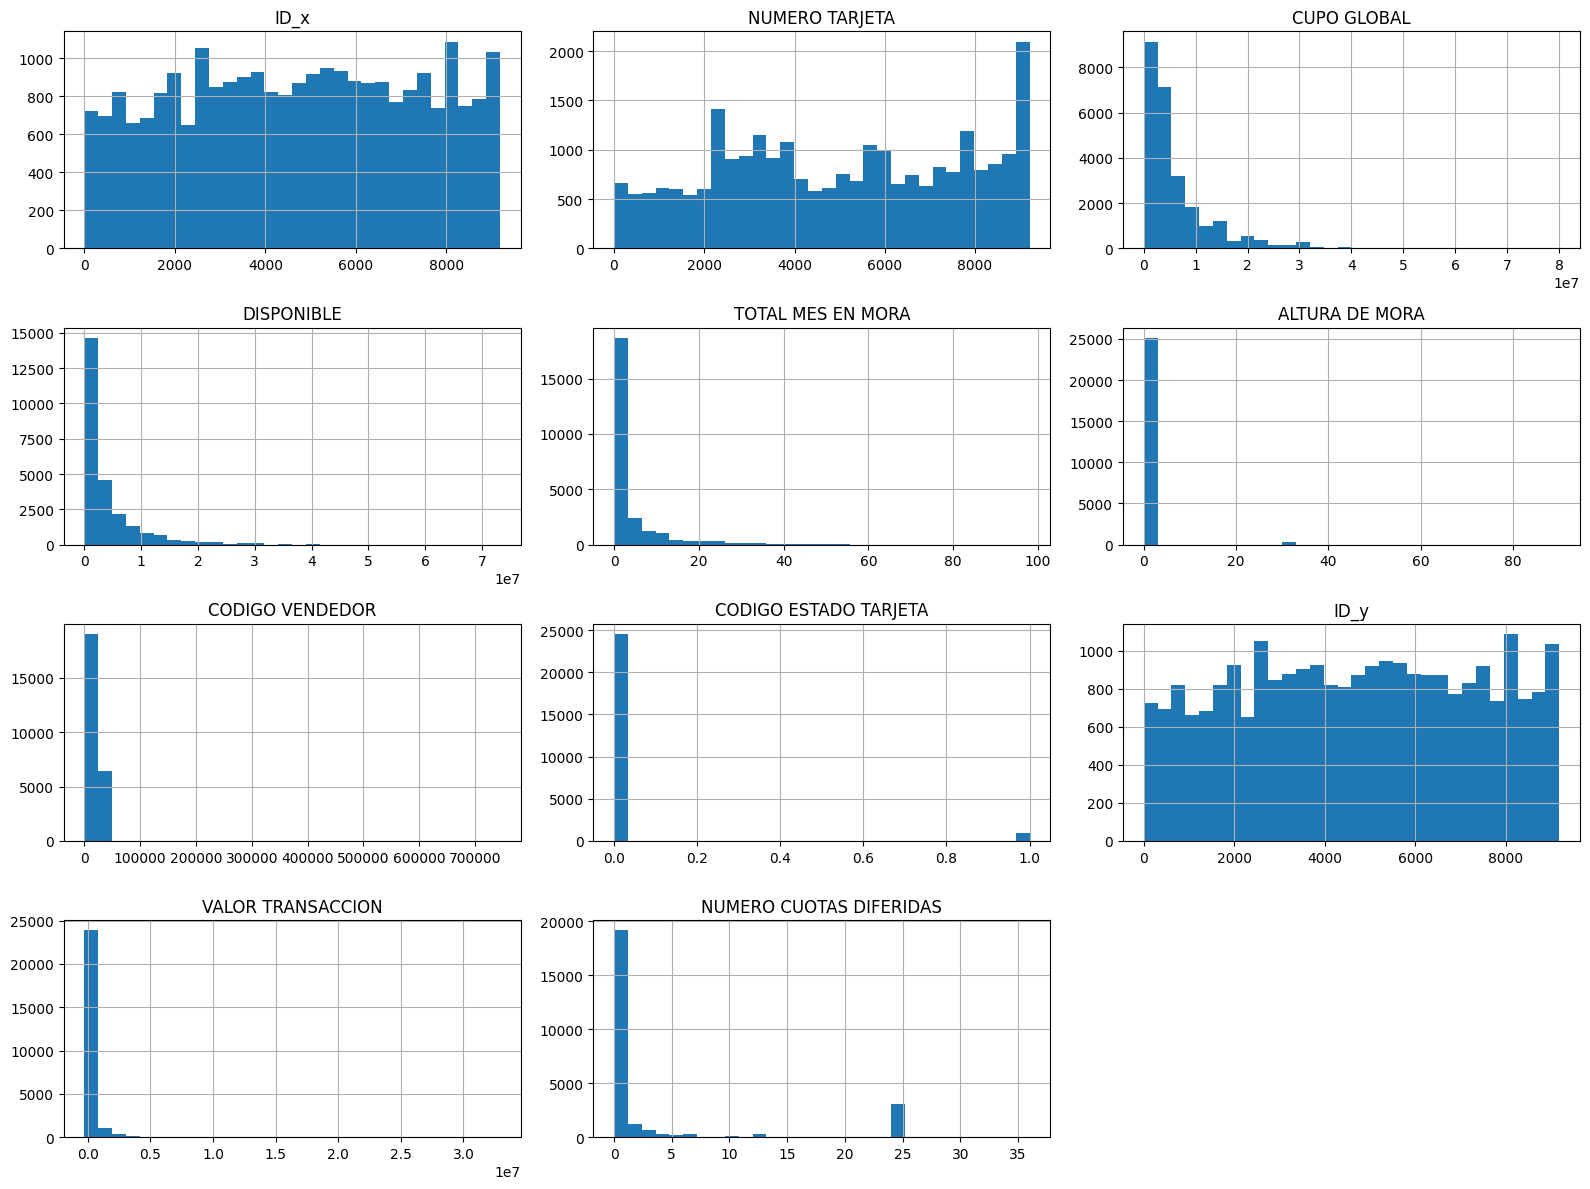

In [73]:
import matplotlib as plt
num_cols = df.select_dtypes(include='number').columns
print(num_cols)
df[num_cols].hist(figsize=(16, 12), bins=30)
plt.pyplot.tight_layout()
plt.pyplot.show()

6. Agrupe los datos por tipo de tarjeta y estado de la tarjeta. Hága un conteo ¿Existe alguna relación entre el tipo de tarjeta y la cancelación de la misma?


In [76]:
conteo = (df.groupby(['TIPO TARJETA', 'CODIGO ESTADO TARJETA']).size().reset_index(name='CONTEO'))

In [77]:
tabla_pct = pd.crosstab(df['TIPO TARJETA'],df['CODIGO ESTADO TARJETA'],normalize='index') * 100

print(tabla_pct.round(2))

CODIGO ESTADO TARJETA       0      1
TIPO TARJETA                        
 C                      88.89  11.11
AZUL                    95.14   4.86
B CLASICA               94.07   5.93
B DORADA                99.36   0.64
C CLASICA               96.19   3.81
C PLATINUM              99.27   0.73
CLASICA C               96.46   3.54
CLASICA TRADICIONAL     94.65   5.35
E-CARD                  94.08   5.92
IDEAL                   93.49   6.51
ORO                     99.08   0.92
ORO C                   98.68   1.32
ORO EXITO              100.00   0.00
ORO TRADICIONAL         97.33   2.67
PLATINUM                99.43   0.57
PLATINUM C             100.00   0.00
VERDE                   95.61   4.39


Existe una relacion positiva entre el tipo de tarjeta y su cancelacion, más basicas son más canceladas

In [88]:
bins = [-1, 0, 3, np.inf]
labels = ['baja mora', 'media mora', 'alta mora']
df['CATEGORIA_MORA'] = pd.cut(df['TOTAL MES EN MORA'],bins=bins,labels=labels)

In [89]:
tabla_mora = pd.crosstab(df['CATEGORIA_MORA'],df['CODIGO ESTADO TARJETA'])
print(tabla_mora)

CODIGO ESTADO TARJETA      0    1
CATEGORIA_MORA                   
baja mora              11553  519
media mora              6364  246
alta mora               6612  151


In [90]:
tabla_mora_pct = pd.crosstab(df['CATEGORIA_MORA'],df['CODIGO ESTADO TARJETA'],normalize='index') * 100
print(tabla_mora_pct.round(2))

CODIGO ESTADO TARJETA      0     1
CATEGORIA_MORA                    
baja mora              95.70  4.30
media mora             96.28  3.72
alta mora              97.77  2.23


Parece ser que no hay relacion entre la Mora y la cancelacion de la tarjeta

8. Haga un gráfico de dispersión 'CODIGO VENDEDOR' vs 'CODIGO ESTADO TARJETA', ¿El vendedor de la tarjeta influencia las cancelaciones?.

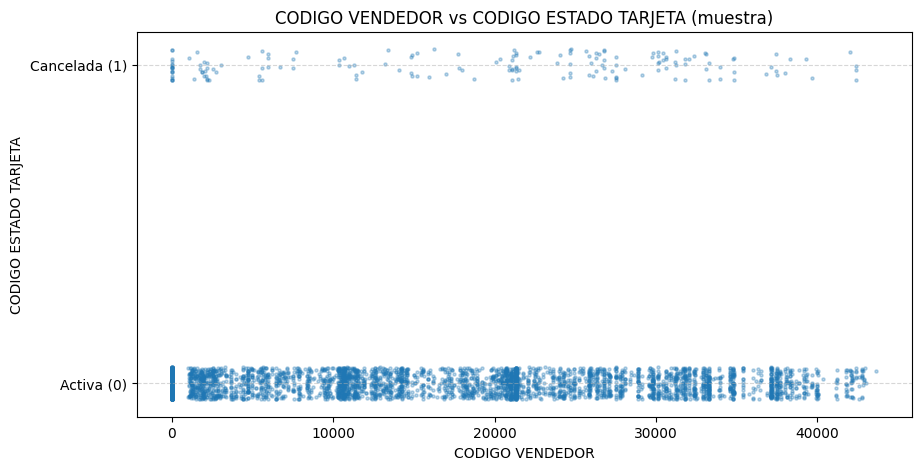

In [92]:
muestra = df.sample(n=5000, random_state=0) if len(df) > 5000 else df.copy()
y_jitter = muestra['CODIGO ESTADO TARJETA'] + np.random.uniform(-0.05, 0.05, size=len(muestra))
plt.pyplot.figure(figsize=(10, 5))
plt.pyplot.scatter(muestra['CODIGO VENDEDOR'], y_jitter, s=5, alpha=0.3)
plt.pyplot.yticks([0, 1], ['Activa (0)', 'Cancelada (1)'])
plt.pyplot.xlabel('CODIGO VENDEDOR')
plt.pyplot.ylabel('CODIGO ESTADO TARJETA')
plt.pyplot.title('CODIGO VENDEDOR vs CODIGO ESTADO TARJETA (muestra)')
plt.pyplot.grid(axis='y', linestyle='--', alpha=0.5)
plt.pyplot.show()

In [93]:
cpv = pd.crosstab(df['CODIGO VENDEDOR'],df['CODIGO ESTADO TARJETA'],normalize='index') * 100
cpv1 = cpv[1].sort_values(ascending=False)
print(cpv1.head(10))

CODIGO VENDEDOR
27505    100.0
31819    100.0
14875    100.0
18703    100.0
12857    100.0
14846    100.0
17966    100.0
26490    100.0
17752    100.0
39974    100.0
Name: 1, dtype: float64


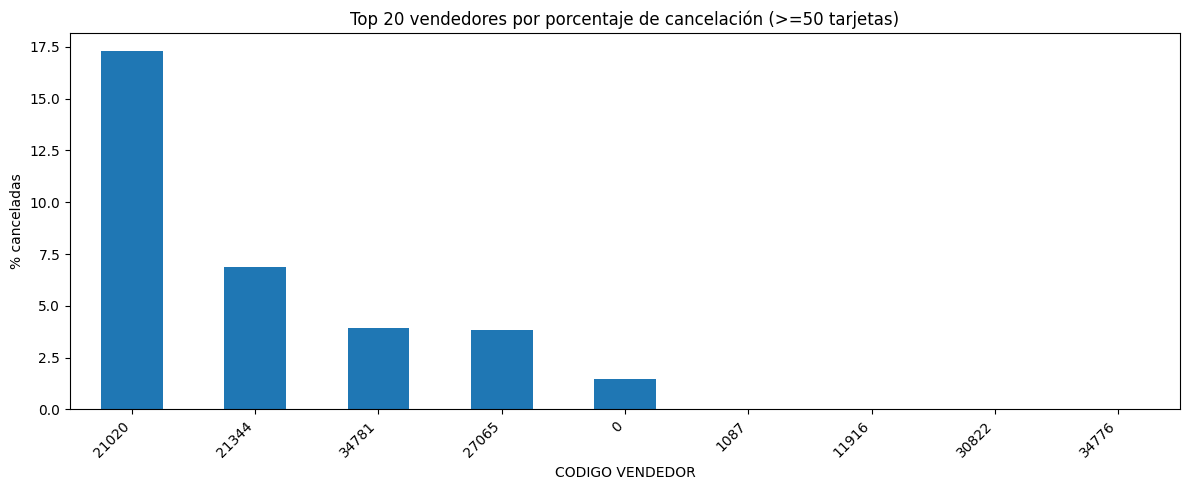

In [96]:
vende = (df.groupby('CODIGO VENDEDOR')['CODIGO ESTADO TARJETA'].agg(total='size', canceladas='sum'))
vende['pct_cancel'] = 100 * vende['canceladas'] / vende['total']
filtrado = vende[vende['total'] >= 50]
top20 = filtrado.sort_values('pct_cancel', ascending=False).head(20)

plt.pyplot.figure(figsize=(12, 5))
top20['pct_cancel'].plot(kind='bar')
plt.pyplot.ylabel('% canceladas')
plt.pyplot.title('Top 20 vendedores por porcentaje de cancelación (>=50 tarjetas)')
plt.pyplot.xticks(rotation=45, ha='right')
plt.pyplot.tight_layout()
plt.pyplot.show()

Definitivamente el 21020 tiene una facilidad para que sus usuarios cancelen